In [1]:
import sys
print(sys.executable)

d:\anaconda3\envs\dl\python.exe


In [2]:
%load_ext autoreload
%autoreload 2

# 1. 导包+全局变量

In [3]:
import GetData
import Model
import Train

import torch 
from torch.utils.data import TensorDataset,DataLoader
import numpy as np

import matplotlib.pyplot as plt


In [4]:
EPOCHS=100
PRINT_EPOC=10
BATCH_SIZE=256  # 原论文128
lr=2e-4
wd=0

device="cuda:0" if torch.cuda.is_available() else "cpu"
IN_CHANNELS=3
HIDDEN_CHANNELS=128
OUT_CHANNELS=3
RESIDUAL_CHANNELS=32
RESIDUAL_LAYERS=4
NUM_EMBEDDINGS=512    
EMBEDDING_DIM=128
DECAY=0.99
COMMIT_COST=0.25

mean=[0.4914, 0.4822, 0.4465]
std=[0.2470, 0.2435, 0.2616]

# 2. 准备数据

## 2.1 获取加载器+标签字典

In [5]:
train_loader,test_loader=GetData.get_CIFAR(BATCH_SIZE)
cifar10_labels = {
    0: 'airplane', 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer',
    5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'
}

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


## 2.2 可视化

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2877722..2.1264887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9259666..2.115826].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9894737..2.0591094].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2908947..1.696086].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3702787..1.9493337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5766771.

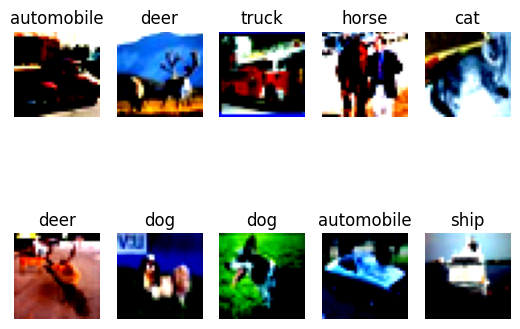

In [6]:
first_train_batch=next(iter(train_loader))
first_test_batch=next(iter(train_loader))

first_train_batch_image=first_train_batch[0][:10].permute(0,2,3,1)
first_train_batch_label=first_train_batch[1][:10]
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(first_train_batch_image[i])
    plt.title(cifar10_labels[first_train_batch_label[i].item()])
    plt.axis("off")
plt.show()

# 3. 训练

In [7]:
init_model=Model.Model(
    IN_CHANNELS,HIDDEN_CHANNELS,OUT_CHANNELS,
    RESIDUAL_CHANNELS,RESIDUAL_LAYERS,
    NUM_EMBEDDINGS,EMBEDDING_DIM,DECAY,COMMIT_COST
)

epoch: 10
reconstruction loss=0.13352644757270812
commit loss=0.017267487483620645
total loss=0.15079393546581268
perplexity=28.73746549560547



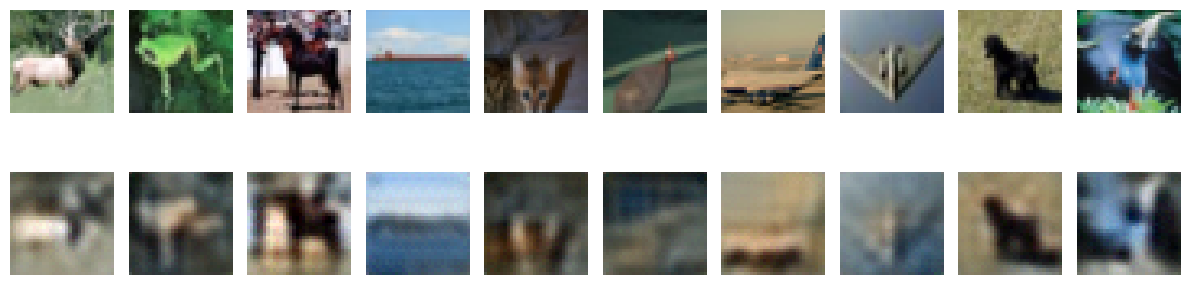

epoch: 20
reconstruction loss=0.09476702890872955
commit loss=0.020631819888949396
total loss=0.11539884886741639
perplexity=79.26767495849609



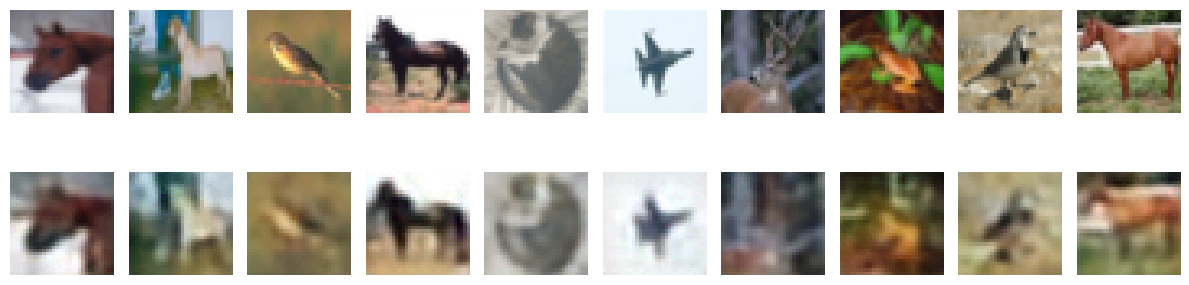

epoch: 30
reconstruction loss=0.07679756878376007
commit loss=0.02608461716711521
total loss=0.10288218571901321
perplexity=165.33448181152343



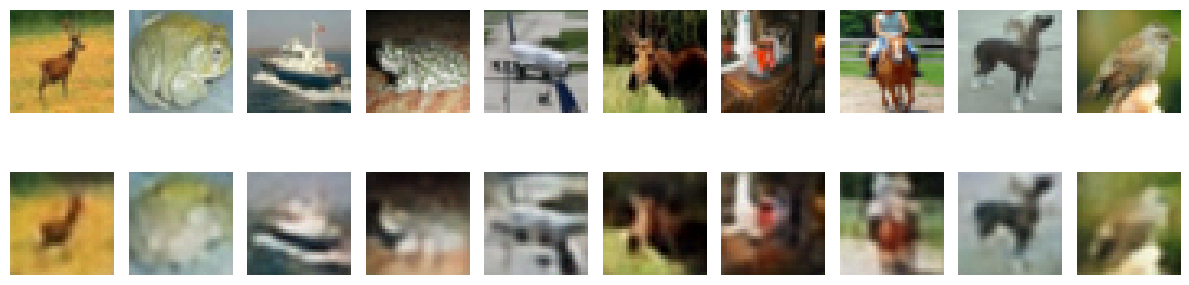

epoch: 40
reconstruction loss=0.06630217126846313
commit loss=0.03130672725737095
total loss=0.09760889837026596
perplexity=274.9403465234375



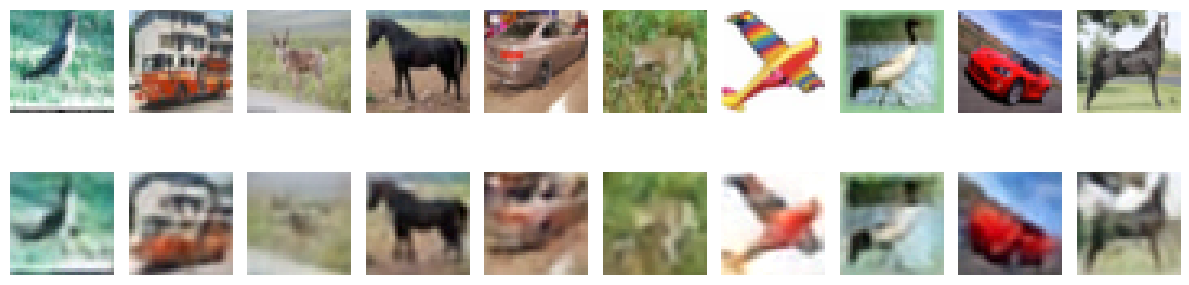

epoch: 50
reconstruction loss=0.05938731970191002
commit loss=0.03291159665107727
total loss=0.09229891632080078
perplexity=402.4552666503906



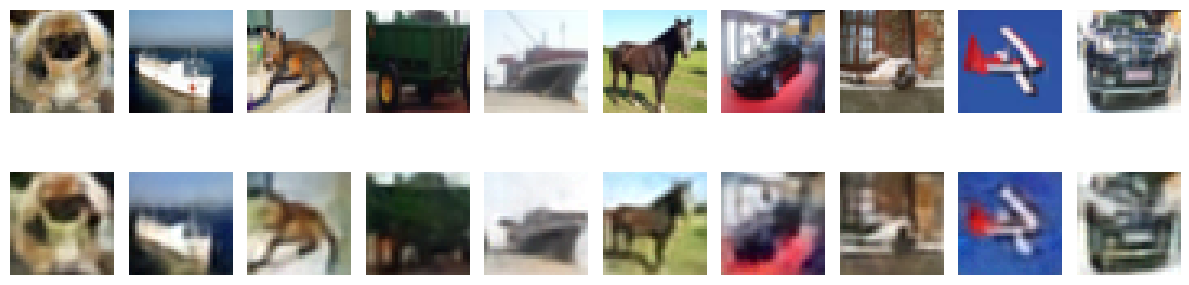

epoch: 60
reconstruction loss=0.05674018960118294
commit loss=0.03603954822659493
total loss=0.09277973775148392
perplexity=405.09687158203127



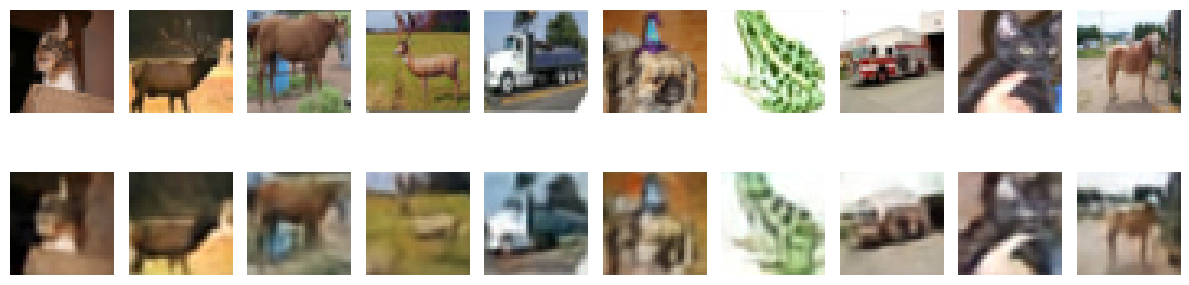

epoch: 70
reconstruction loss=0.055546693353652955
commit loss=0.038695742186307905
total loss=0.09424243533611297
perplexity=403.17722725585935



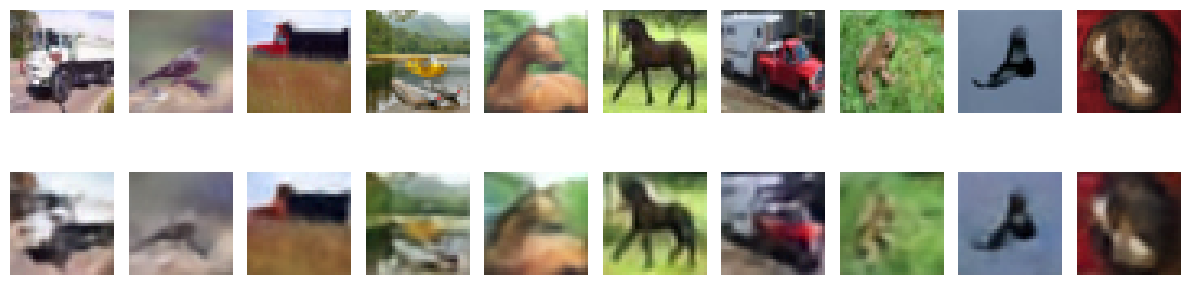

epoch: 80
reconstruction loss=0.05460674523234367
commit loss=0.040678689370155334
total loss=0.09528543466567993
perplexity=402.4646666796875



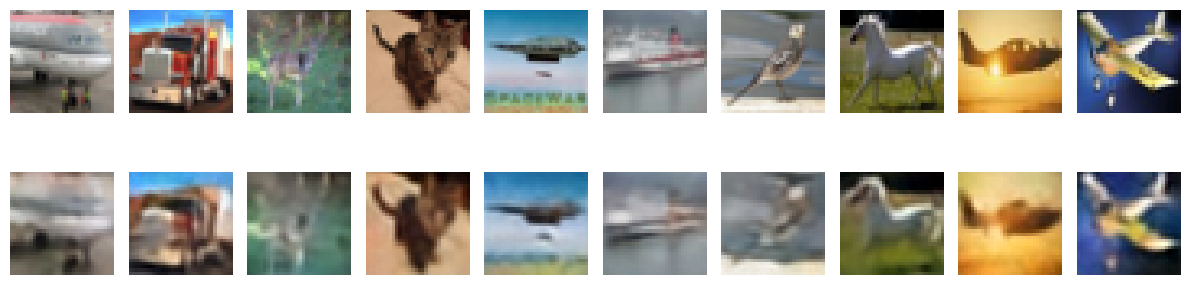

epoch: 90
reconstruction loss=0.05394102882027626
commit loss=0.04226455433487892
total loss=0.0962055832695961
perplexity=402.4530245898438



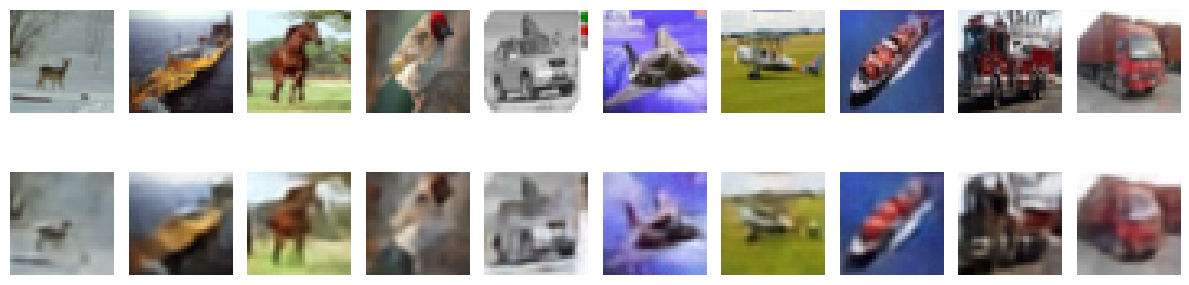

epoch: 100
reconstruction loss=0.05359154900074005
commit loss=0.043473037482500074
total loss=0.09706458657264709
perplexity=402.3523585253906



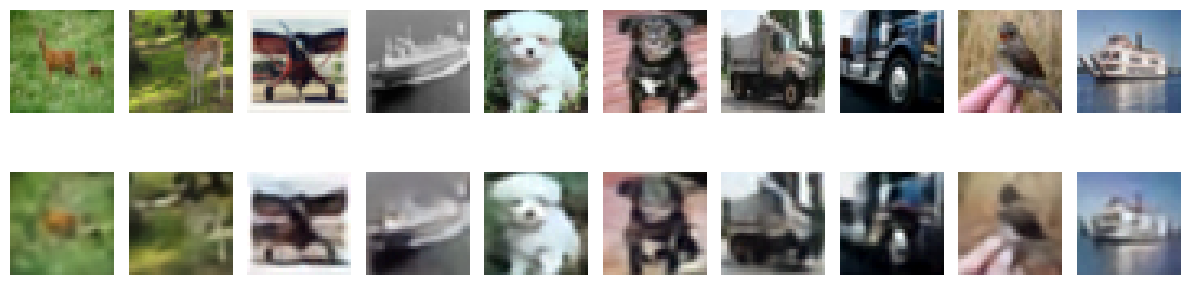

In [8]:
perplexity_list,loss_list,recon_loss_list,commit_loss_list,best_model=Train.train_pipeline(
    init_model,train_loader,EPOCHS,PRINT_EPOC,lr,wd,device,
    mean,std
)

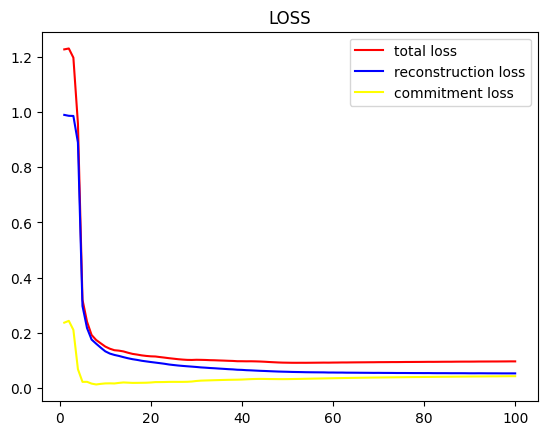

In [13]:
plt.plot(torch.arange(1,EPOCHS+1),loss_list,"red",label="total loss")
plt.plot(torch.arange(1,EPOCHS+1),recon_loss_list,"blue",label="reconstruction loss")
plt.plot(torch.arange(1,EPOCHS+1),commit_loss_list,"yellow",label="commitment loss")

plt.legend()
plt.title("LOSS")
plt.show()

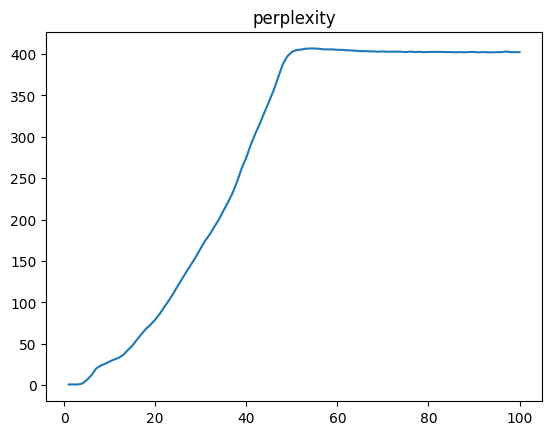

In [14]:
plt.plot(torch.arange(1,EPOCHS+1),perplexity_list)
plt.title("perplexity")
plt.show()

In [15]:
import os

SAVE_DIR = r"..\checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, "best_vqvae_cifar.pt")

torch.save({
    "model_state_dict": best_model.state_dict(),
    "loss_list": loss_list,
    "recon_loss_list": recon_loss_list,
    "commit_loss_list": commit_loss_list,
    "perplexity_list": perplexity_list,
    "best_loss": min(loss_list),
    "config": {
        "IN_CHANNELS": IN_CHANNELS,
        "HIDDEN_CHANNELS": HIDDEN_CHANNELS,
        "OUT_CHANNELS": OUT_CHANNELS,
        "RESIDUAL_CHANNELS": RESIDUAL_CHANNELS,
        "RESIDUAL_LAYERS": RESIDUAL_LAYERS,
        "NUM_EMBEDDINGS": NUM_EMBEDDINGS,
        "EMBEDDING_DIM": EMBEDDING_DIM,
        "DECAY": DECAY,
        "COMMIT_COST": COMMIT_COST,
    },
}, SAVE_PATH)

print(f"best model saved to: {SAVE_PATH}")
print(f"best total loss: {min(loss_list):.6f}")

best model saved to: ..\checkpoints\best_vqvae_cifar.pt
best total loss: 0.091955


# 4. 测试集重建

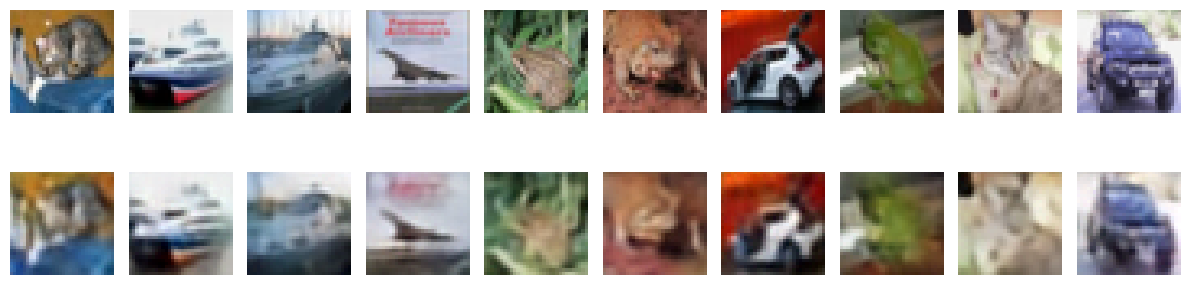

In [ ]:
Train.valid(best_model,test_loader,device,mean,std,1)